# fNIRS connectivity demo

Python port of the nirs-toolbox `demos/fnirs_connectivity_demo.m` example.

The original MATLAB demo used experimental resting-state data downloaded from the web. Here all examples use the
simulated data with a **known** connectivity pattern from `pyBrainAnalyzIR.testing.simData`:

* `simData.connectivity_shortsep()` – port of `nirs.testing.simData_connectivity_shortsep`. Brain connectivity between
  long-separation channels plus spatially smooth superficial (skin) noise modeled with the analytic slab forward model
  (`pyBrainAnalyzIR.forward.ApproxSlab`). Short-separation (~7 mm) channels only see the skin noise.
* `simData.connectivity()` – port of `nirs.testing.simData_connectivity`. Lagged/directed (MVAR) connectivity added to
  an AR-noise recording.

Sections:
1. The problem of serially-correlated errors
2. Sensitivity-specificity of the correlation models
3. Using the connectivity module (plus short-separation regression)
4. Hyperscanning

Graph-theory measures and group-level (mixed effects) connectivity from the MATLAB demo are not included yet.

In [1]:
import copy
import numpy as np
import pandas as pd
import scipy.signal
import scipy.stats
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

import cedalion
import cedalion.nirs

import pyBrainAnalyzIR
import pyBrainAnalyzIR.testing.simData as simData
import pyBrainAnalyzIR.pipelines.modules.preproccessing as prep
import pyBrainAnalyzIR.dataclasses.dataset as dataset
from pyBrainAnalyzIR.pipelines.modules.connectivity import resting_state_connectivity, hyperscanning
from pyBrainAnalyzIR.math.connectivity import pearson_corrcoef
from pyBrainAnalyzIR.math.corrcoef_robust import corrcoef as robust_corrcoef
from pyBrainAnalyzIR.math.innovations import innovations

import warnings
warnings.filterwarnings('ignore')

# This will allow matplotlib to work as a widget (needs "pip install ipympl")
%matplotlib widget

np.random.seed(42)

### Helper functions
Equivalents of the MATLAB `nirs.sFC.corr`, `nirs.sFC.ar_corr` and `nirs.testing.roc` functions used in the demo.

In [2]:
def corr(Y):
    """Pearson correlation and p-values of the columns of Y (nirs.sFC.corr)."""
    return pearson_corrcoef(Y)


def ar_corr(Y, pmax=20, robust=True):
    """Correlation of the AR-whitened (innovations) signals (nirs.sFC.ar_corr)."""
    yfilt, f = innovations(Y, pmax)
    yfilt = yfilt[len(f[0]):]  # drop the filter start-up samples
    return robust_corrcoef(yfilt) if robust else pearson_corrcoef(yfilt)


def roc(truth, pval):
    """True/false positive rates vs. p-value threshold (nirs.testing.roc)."""
    truth = np.asarray(truth, dtype=bool)
    pval = np.asarray(pval, dtype=float)
    lst, lstN = np.where(truth)[0], np.where(~truth)[0]
    if len(lst) != len(lstN) and truth.any():
        n = min(len(lst), len(lstN))
        idx = np.concatenate([np.random.permutation(lst)[:n], np.random.permutation(lstN)[:n]])
        truth, pval = truth[idx], pval[idx]
    order = np.argsort(pval)
    tp = np.cumsum(truth[order]) / max(truth.sum(), 1)
    fp = np.cumsum(~truth[order]) / max((~truth).sum(), 1)
    return tp, fp, pval[order]


def canonical_hrf(fs, duration=20):
    """Double-gamma canonical HRF sampled at fs (Hz)."""
    t = np.arange(0, duration + 1 / fs, 1 / fs)
    h = scipy.stats.gamma.pdf(t, 6) - scipy.stats.gamma.pdf(t, 16) / 6
    return h / h.sum()

## Example 1. Statement of the problem
Before we look at the toolbox, let's look at the problem of serially-correlated errors in a time series.
We simulate two completely independent white-noise signals ("neural" model), and then convolve them with a
hemodynamic response ("hemodynamic" model). By definition the two signals are uncorrelated, so at p<0.05 we expect
only 5% of the tests to be (falsely) significant.

In [3]:
num_iter = 20        # number of iterations to run
num_timepts = 1000
fs_list = [.5, 1, 4, 20]  # Let's try a few sample rates too

for fs in fs_list:
    P = np.zeros((3, num_iter))
    hrf = canonical_hrf(fs)
    for it in range(num_iter):
        n = np.random.randn(num_timepts, 2)
        h = scipy.signal.lfilter(hrf, 1, n, axis=0)

        P[0, it] = corr(n)[1][0, 1]          # "neural" model
        P[1, it] = corr(h)[1][0, 1]          # "hemodynamic" model
        P[2, it] = ar_corr(h, 20)[1][0, 1]   # AR-whitened (robust) correlation

    print(f'Results at sample rate: {fs}Hz')
    print(f'   "Neural Model" FDR = {np.mean(P[0] < 0.05) * 100:.0f}%  (p<0.05 expected)')
    print(f'   "Hemodynamic Model" FDR = {np.mean(P[1] < 0.05) * 100:.0f}%  (p<0.05 expected)')
    print(f'   AR-filtered "Hemodynamic" FDR = {np.mean(P[2] < 0.05) * 100:.0f}%  (p<0.05 expected)')
    print('-------------------------------')

Results at sample rate: 0.5Hz
   "Neural Model" FDR = 5%  (p<0.05 expected)
   "Hemodynamic Model" FDR = 10%  (p<0.05 expected)
   AR-filtered "Hemodynamic" FDR = 10%  (p<0.05 expected)
-------------------------------


Results at sample rate: 1Hz
   "Neural Model" FDR = 5%  (p<0.05 expected)
   "Hemodynamic Model" FDR = 40%  (p<0.05 expected)
   AR-filtered "Hemodynamic" FDR = 10%  (p<0.05 expected)
-------------------------------
Results at sample rate: 4Hz
   "Neural Model" FDR = 5%  (p<0.05 expected)
   "Hemodynamic Model" FDR = 75%  (p<0.05 expected)
   AR-filtered "Hemodynamic" FDR = 25%  (p<0.05 expected)
-------------------------------


Results at sample rate: 20Hz
   "Neural Model" FDR = 10%  (p<0.05 expected)
   "Hemodynamic Model" FDR = 90%  (p<0.05 expected)
   AR-filtered "Hemodynamic" FDR = 10%  (p<0.05 expected)
-------------------------------


The model starts to fail at higher sample rates because the maximum AR model order (20, selected by BIC) is too
low to whiten the slow hemodynamic signal (20 samples is only 1 s at 20 Hz).

## Example 2. Sensitivity-specificity
Now let's look at the ROC curves for these methods. Instead of the downloaded experimental data used in the MATLAB
demo, we simulate resting-state recordings with a known connectivity pattern using
`simData.connectivity_shortsep`, which returns the recording and the `truth` pattern (long-separation channels).

In [4]:
num_files = 6
raw = []
truths = []
for i in range(num_files):
    rec, truth = simData.connectivity_shortsep()
    raw.append(rec)
    truths.append(truth)

print(raw[0])
truth

<Recording |  timeseries: ['amp'],  masks: [],  stim: [],  aux_ts: [],  aux_obj: []>


<xarray.DataArray (channel_to: 16, channel_from: 16)> Size: 2kB
array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.16666667, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.2       , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.33333333, 0.        , 0.        ,
        0.2       , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.16666667, 0.        , 0.        , 0.        , 0.        ,
        0.2       , 0.2       , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.25      ,
        0.        , 0.        , 0.        , 0.        , 0.33333333,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.2       , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
...
       [0.        , 0.        , 0.2       , 0.        , 0.        ,
        0.4       , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.2       , 0.        , 0.2       , 0.2       ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.2       , 0.        , 0.        , 0.        , 0.        ,
        0.2       , 0.2       , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.33333333, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.33333333, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ]])
Coordinates:
  * channel_to    (channel_to) <U5 320B 'S1D1' 'S2D1' 'S2D2' ... 'S8D8' 'S9D8'
  * channel_from  (channel_from) <U5 320B 'S1D1' 'S2D1' 'S2D2' ... 'S8D8' 'S9D8'

In [5]:
# Resample to 1Hz -> optical density -> hemoglobin (modified Beer-Lambert law)
job = prep.resample()
job.options['Fs'] = 1  # go to 1Hz sample rate
job = prep.intensity_opticaldensity(job)
job = prep.mbll(job)
hb = [job.run(copy.deepcopy(rec)) for rec in raw]  # keep the raw 10Hz recordings unchanged


def long_hbo(rec):
    # The truth is defined over the long-separation channels
    ts_long, _ = cedalion.nirs.split_long_short_channels(rec['conc'], rec.geo3d)
    return ts_long.sel(chromo='HbO').transpose('time', 'channel').pint.dequantify()


hbo = [long_hbo(rec) for rec in hb]
hbo[0]

<xarray.DataArray 'concentration' (time: 300, channel: 16)> Size: 38kB
array([[-0.39056841, -0.71483722, -1.1295119 , ..., -1.31625053,
         0.49566562,  0.63776633],
       [ 0.05857196, -0.04773498, -0.68041021, ..., -0.72721361,
         0.96202503,  1.01364758],
       [-0.36395313, -0.48175709, -0.674822  , ..., -0.67108323,
         0.79538226,  0.47812739],
       ...,
       [-2.5626984 , -1.69333052,  0.78882992, ...,  1.37284016,
         1.76096928,  1.44610319],
       [-2.67554785, -1.82724611,  0.56935922, ...,  1.3419604 ,
         1.83363184,  1.0858114 ],
       [-2.23996826, -1.63604418,  1.02799551, ...,  1.62507338,
         2.80404158,  1.42933667]], shape=(300, 16))
Coordinates:
    chromo    <U3 12B 'HbO'
    samples   (time) float64 2kB 0.0 10.0 20.0 ... 2.97e+03 2.98e+03 2.99e+03
  * channel   (channel) <U5 320B 'S1D1' 'S2D1' 'S2D2' ... 'S8D7' 'S8D8' 'S9D8'
    source    (channel) <U2 128B 'S1' 'S2' 'S2' 'S3' ... 'S7' 'S8' 'S8' 'S9'
    detector  (channel) <U3 192B 'D1' 'D1' 'D2' 'D2' ... 'D7' 'D7' 'D8' 'D8'
  * time      (time) float64 2kB 0.0 1.0 2.0 3.0 4.0 ... 296.0 297.0 298.0 299.0
Attributes:
    units:    micromolar

We take two time traces either from the same file with a true connection between them (true positive) or from two
different files (true negative) and test each model's performance.

In [6]:
num_iter = 100
Ppos = np.zeros((num_iter, 3))
Pneg = np.zeros((num_iter, 3))

for it in range(num_iter):
    # True positive: two truly connected channels from the same file
    i = np.random.randint(num_files)
    to_idx, from_idx = np.nonzero(np.triu(truths[i].values))
    k = np.random.randint(len(to_idx))
    chans = [truths[i].channel_to.values[to_idx[k]], truths[i].channel_from.values[from_idx[k]]]
    nPos = hbo[i].sel(channel=chans).values

    # True negative: two channels from two different files
    i, j = np.random.choice(num_files, 2, replace=False)
    a = hbo[i].values[:, np.random.randint(hbo[i].shape[1])]
    b = hbo[j].values[:, np.random.randint(hbo[j].shape[1])]
    ntps = min(len(a), len(b))
    nNeg = np.column_stack([a[:ntps], b[:ntps]])

    for m, fcn in enumerate([corr,
                             lambda d: ar_corr(d, 20, robust=False),
                             lambda d: ar_corr(d, 20, robust=True)]):
        Ppos[it, m] = fcn(nPos)[1][0, 1]
        Pneg[it, m] = fcn(nNeg)[1][0, 1]

for m, name in enumerate(['normal correlation', 'AR-correlation', 'robust AR-correlation']):
    print(f'For the {name} model @ p<0.05')
    print(f'   True positives rate: {np.mean(Ppos[:, m] < 0.05):.2f}')
    print(f'   False negatives rate: {np.mean(Ppos[:, m] >= 0.05):.2f}')
    print(f'   True negatives rate: {np.mean(Pneg[:, m] >= 0.05):.2f}')
    print(f'   False positives rate: {np.mean(Pneg[:, m] < 0.05):.2f}')

For the normal correlation model @ p<0.05
   True positives rate: 1.00
   False negatives rate: 0.00
   True negatives rate: 0.37
   False positives rate: 0.63
For the AR-correlation model @ p<0.05
   True positives rate: 1.00
   False negatives rate: 0.00
   True negatives rate: 0.97
   False positives rate: 0.03
For the robust AR-correlation model @ p<0.05
   True positives rate: 1.00
   False negatives rate: 0.00
   True negatives rate: 0.97
   False positives rate: 0.03


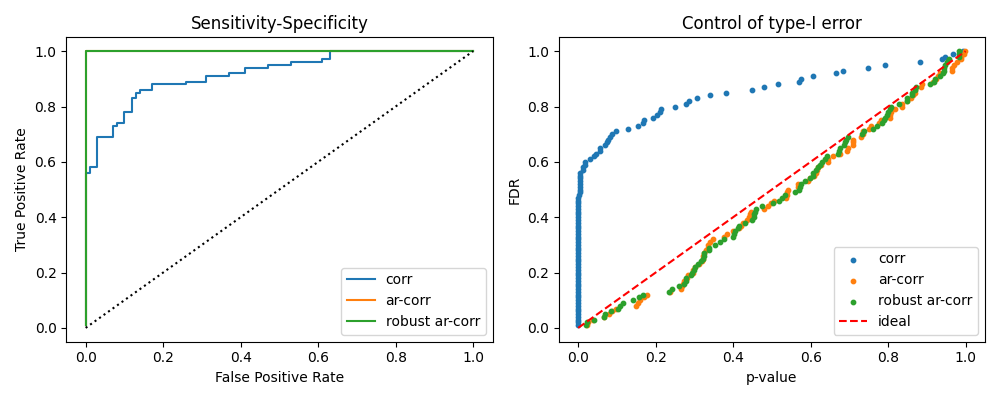

In [7]:
labels = ['corr', 'ar-corr', 'robust ar-corr']
truth_vec = np.concatenate([np.ones(num_iter), np.zeros(num_iter)])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for m, name in enumerate(labels):
    tp, fp, th = roc(truth_vec, np.concatenate([Ppos[:, m], Pneg[:, m]]))
    ax[0].plot(fp, tp, label=name)

    # control of the type-I error (negatives only)
    tp, fp, th = roc(np.zeros(num_iter), Pneg[:, m])
    ax[1].scatter(th, fp, s=10, label=name)

ax[0].plot([0, 1], [0, 1], 'k:')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Sensitivity-Specificity')
ax[0].legend()
ax[1].plot([0, 1], [0, 1], 'r--', label='ideal')
ax[1].set_xlabel('p-value')
ax[1].set_ylabel('FDR')
ax[1].set_title('Control of type-I error')
ax[1].legend()
plt.tight_layout()

The normal correlation model has a very high false-positive rate because of the serially correlated (colored)
noise. The AR-whitened models control the type-I error close to the nominal p-value.

## Example 3. The connectivity module
Now that we have seen the performance of the various models, let's use them within the pipeline code. The
`resting_state_connectivity` module computes the (robust, AR-whitened) correlation between all channels. Here we use
an AR model order of 4 at the 1 Hz sample rate (the `'4xFs'` default of the MATLAB toolbox).

The module also has a `short_separation_correction` flag (default `True`) that removes the superficial physiology
using the short-separation channels. To mimic the MATLAB demo, we first turn it off.

In [8]:
# for speed, let's just run this on our first 4 files
dset = dataset.DataSet()
for rec in raw[:4]:
    dset.import_data(copy.deepcopy(rec))

job = prep.resample()
job.options['Fs'] = 1  # go to 1Hz sample rate
job = prep.intensity_opticaldensity(job)
job = prep.mbll(job)
job = resting_state_connectivity(job)
job.options['AR'] = 4
job.options['robust'] = True
job.options['short_separation_correction'] = False
job.show()

Resample:
Options:
	Fs : 1
Calculate Optical Density:
Options:
	<none>
Calculate Modified Beer-Lambert:
	Citation: Cope & Delpy:

Options:
	spectrum : prahl
	dpf      : [6, 6]
Resting State Connectivity:
	Citation: Santosa, Hendrik, et al. 'Characterization and correction of the false-discovery rates in resting state connectivity using functional near-infrared spectroscopy.' Journal of biomedical optics 22.5 (2017): 055002-055002.:

Options:
	AR                           : 4
	robust                       : True
	divide_events                : False
	min_event_duration           : 30
	ignore_event_transition_time : 10
	short_separation_correction  : False


In [9]:
dset = job.run(dset)

ConnStats = dset.dataset[0]['conn']
ConnStats.coef

,Coeff,Pvalue,Condition,Channel_to,Channel_from,Type_to,Type_from,dfe,ZstdErr,geo_to,geo_from
0,1.000000,1.000000e+00,rest,S1D1,S1D1,HbO,HbO,298.0,0.058026,default,default
1,0.813756,3.340661e-72,rest,S2D1,S1D1,HbO,HbO,298.0,0.058026,default,default
2,0.416653,5.005367e-14,rest,S2D2,S1D1,HbO,HbO,298.0,0.058026,default,default
3,0.438277,1.637590e-15,rest,S3D2,S1D1,HbO,HbO,298.0,0.058026,default,default
4,0.365811,6.253184e-11,rest,S3D3,S1D1,HbO,HbO,298.0,0.058026,default,default
...,...,...,...,...,...,...,...,...,...,...,...
1245,0.700632,1.358189e-45,rest,S5D13,S9D17,HbR,HbR,298.0,0.058026,default,default
1246,0.820662,2.093356e-74,rest,S6D14,S9D17,HbR,HbR,298.0,0.058026,default,default
1247,0.912747,7.026413e-118,rest,S7D15,S9D17,HbR,HbR,298.0,0.058026,default,default
1248,0.974021,2.893847e-194,rest,S8D16,S9D17,HbR,HbR,298.0,0.058026,default,default


You can draw the connectivity maps (here thresholded at q<0.05). Note that the short-separation channels (Sx-D9..D17)
are included and that many long-channel pairs appear connected: the superficial (skin) physiology is shared by all
channels.

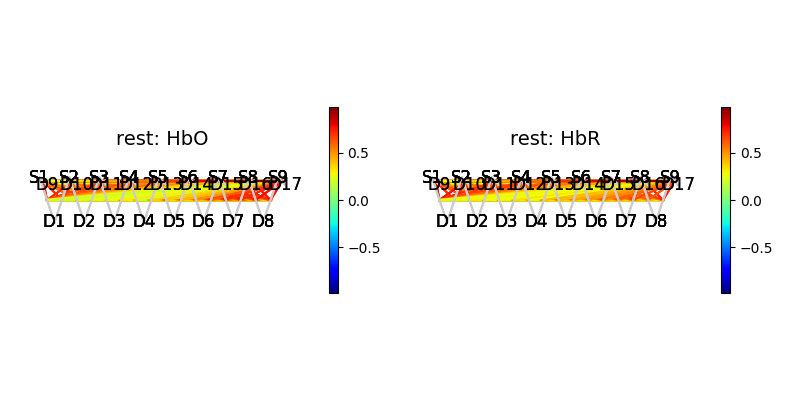

In [10]:
ConnStats.show(thres=0.05, threshold_type='q')

For comparison, the true connectivity pattern of this file can be drawn with the same function by placing the known
`truth` into a copy of the connectivity object.

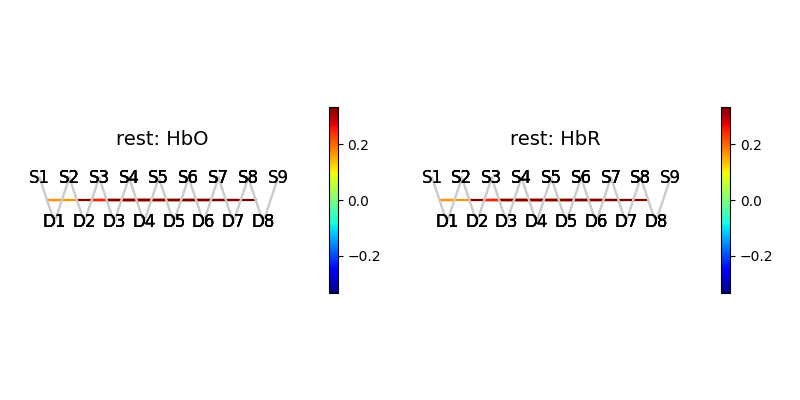

In [11]:
def truth_as_connectivity(conn, truth):
    """Copy of a Connectivity object whose coefficients show the simulated truth."""
    tconn = conn.copy()
    coef = tconn.coef
    coef = coef[coef.Channel_to.isin(truth.channel_to.values) &
                coef.Channel_from.isin(truth.channel_from.values)].reset_index(drop=True)
    coef['Coeff'] = [truth.sel(channel_to=r.Channel_to, channel_from=r.Channel_from).item()
                     for r in coef.itertuples()]
    coef['Pvalue'] = np.where(coef.Coeff != 0, 0.0, 1.0)
    tconn.coef = coef
    return tconn


truth_as_connectivity(ConnStats, truths[0]).show(thres=0.05, threshold_type='p')

### Short-separation regression
The short-separation channels only measure the superficial signal, so regressing the nearest short channel out of
each long channel removes most of the shared skin physiology before computing the connectivity. With
`short_separation_correction=True` (the default) the connectivity module runs the `ShortSeparationFilter` module
(`pyBrainAnalyzIR.pipelines.modules.filters`) internally, computes the connectivity on the filtered long channels, and
then discards the intermediate filtered data.

['amp', 'od', 'conc', 'conn', 'conn_ss']


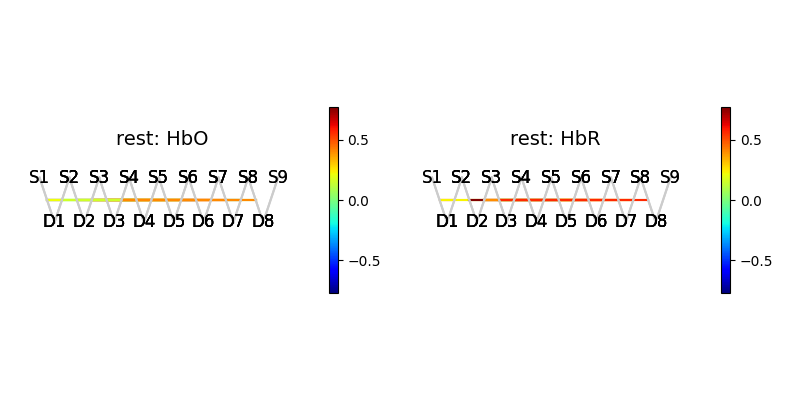

In [12]:
job_ss = resting_state_connectivity()
job_ss.inputName = 'conc'
job_ss.outputName = 'conn_ss'
job_ss.options['AR'] = 4
job_ss.options['robust'] = True
job_ss.options['short_separation_correction'] = True
dset = job_ss.run(dset)

print(list(dset.dataset[0].timeseries.keys()))
dset.dataset[0]['conn_ss'].show(thres=0.05, threshold_type='q')

Finally, let's pool all the files and compare the ROC curves of the connectivity estimates (HbO, unique long-channel
pairs) with and without short-separation regression.

no SS regression: sensitivity=1.00  false positive rate=0.99  (p<0.05)
SS regression: sensitivity=0.96  false positive rate=0.15  (p<0.05)


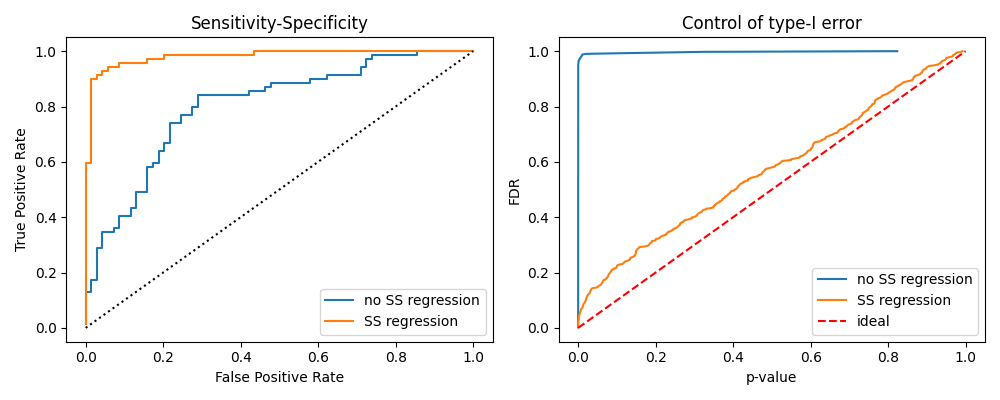

In [13]:
def conn_truth_pvalues(conn, truth, chromo='HbO'):
    coef = conn.coef
    coef = coef[(coef.Type_to == chromo) & (coef.Type_from == chromo) &
                coef.Channel_to.isin(truth.channel_to.values) &
                coef.Channel_from.isin(truth.channel_from.values) &
                (coef.Channel_to < coef.Channel_from)]
    t = np.array([truth.sel(channel_to=r.Channel_to, channel_from=r.Channel_from).item() != 0
                  for r in coef.itertuples()])
    return t, coef.Pvalue.values


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name in ['conn', 'conn_ss']:
    tt, pp = zip(*[conn_truth_pvalues(rec[name], truths[i]) for i, rec in enumerate(dset.dataset)])
    tt, pp = np.concatenate(tt), np.concatenate(pp)
    label = 'no SS regression' if name == 'conn' else 'SS regression'
    tp, fp, th = roc(tt, pp)
    ax[0].plot(fp, tp, label=label)
    tp, fp, th = roc(np.zeros((~tt).sum()), pp[~tt])
    ax[1].plot(th, fp, label=label)
    print(f'{label}: sensitivity={np.mean(pp[tt] < 0.05):.2f}  false positive rate={np.mean(pp[~tt] < 0.05):.2f}  (p<0.05)')

ax[0].plot([0, 1], [0, 1], 'k:')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Sensitivity-Specificity')
ax[0].legend()
ax[1].plot([0, 1], [0, 1], 'r--', label='ideal')
ax[1].set_xlabel('p-value')
ax[1].set_ylabel('FDR')
ax[1].set_title('Control of type-I error')
ax[1].legend()
plt.tight_layout()

Short-separation regression greatly improves the sensitivity-specificity, although some false positives remain
because the short channels sample the skin under a slightly different region than the long channels.

### Lagged (Granger-like) connectivity: `simData.connectivity`
`simData.connectivity` simulates directed connections at different lags using a multivariate AR model. Its truth is
indexed by (`channel_to`, `wavelength_to`, `channel_from`, `wavelength_from`, `lag`). Zero-lag correlation only
partially detects these lagged connections.

In [14]:
rec_mvar, truth_mvar = simData.connectivity(pmax=5)
truth_mvar

<xarray.DataArray (channel_to: 16, wavelength_to: 2, channel_from: 16,
                   wavelength_from: 2, lag: 6)> Size: 49kB
array([[[[[1., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         ...,

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]]],

...

        [[[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 1., 0., 0.]],

         [[0., 0., 0., 0., 1., 0.],
          [0., 0., 0., 0., 0., 0.]],

         ...,

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [1., 0., 0., 0., 0., 0.]]]]], shape=(16, 2, 16, 2, 6))
Coordinates:
  * channel_to       (channel_to) <U4 256B 'S1D1' 'S2D1' ... 'S8D8' 'S9D8'
  * wavelength_to    (wavelength_to) float64 16B 760.0 850.0
  * channel_from     (channel_from) <U4 256B 'S1D1' 'S2D1' ... 'S8D8' 'S9D8'
  * wavelength_from  (wavelength_from) float64 16B 760.0 850.0
  * lag              (lag) int64 48B 1 2 3 4 5 6

sensitivity=0.55  false positive rate=0.15  (p<0.05)


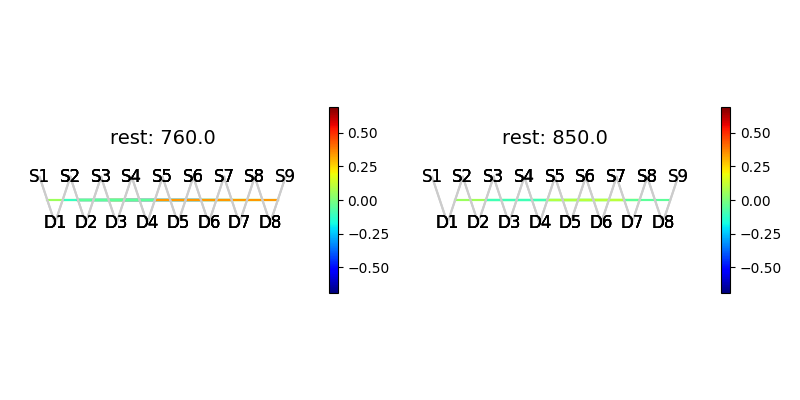

In [15]:
job = prep.intensity_opticaldensity()
job = resting_state_connectivity(job)
job.options['short_separation_correction'] = False  # this probe has no short-separation channels
rec_mvar = job.run(rec_mvar)

# undirected, any-lag truth for the same-wavelength pairs
T = (truth_mvar != 0).any('lag')
coef = rec_mvar['conn'].coef
coef = coef[(coef.Channel_to < coef.Channel_from)]
tt = np.array([bool(T.sel(channel_to=r.Channel_to, channel_from=r.Channel_from,
                           wavelength_to=r.Type_to, wavelength_from=r.Type_from)
                    | T.sel(channel_to=r.Channel_from, channel_from=r.Channel_to,
                            wavelength_to=r.Type_from, wavelength_from=r.Type_to))
               for r in coef.itertuples()])
print(f'sensitivity={np.mean(coef.Pvalue.values[tt] < 0.05):.2f}  '
      f'false positive rate={np.mean(coef.Pvalue.values[~tt] < 0.05):.2f}  (p<0.05)')
rec_mvar['conn'].show(thres=0.05, threshold_type='q')

## Example 4. Hyperscanning
The `hyperscanning` module computes the connectivity between the channels of two (or more) subjects. Its options are
the same as the connectivity module plus the demographics variable that defines which files belong together.

Here we pair up independently simulated recordings. Since these files are unrelated, we expect **no** connections
between the subjects; any significant connection is a false positive. As in the MATLAB demo, we turn the
short-separation correction off here to focus on the statistical model.

In [16]:
num_files = 8
dset_hyper = dataset.DataSet()
for i in range(num_files):
    rec, _ = simData.connectivity_shortsep()
    dset_hyper.import_data(rec)

demo = pd.DataFrame({'subject': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
                     'pair': ['dyad1', 'dyad1', 'dyad2', 'dyad2', 'dyad3', 'dyad3', 'dyad4', 'dyad4']})
dset_hyper.add_demographics_by_index(demo)

job = prep.resample()
job.options['Fs'] = 1  # go to 1Hz sample rate
job = prep.intensity_opticaldensity(job)
job = prep.mbll(job)
dset_hyper = job.run(dset_hyper)
dset_hyper.get_demographics()

,subject,pair
0,A,dyad1
1,B,dyad1
2,C,dyad2
3,D,dyad2
4,E,dyad3
5,F,dyad3
6,G,dyad4
7,H,dyad4


In [17]:
# This is the normal correlation model
job = hyperscanning()
job.inputName = 'conc'
job.outputName = 'hyper_corr'
job.options['grouping_variable'] = 'pair'
job.options['AR'] = 0
job.options['short_separation_correction'] = False
job.options['robust'] = False
dset_hyper = job.run(dset_hyper)

# This is the AR-whitened robust regression version
job.outputName = 'hyper_ar'
job.options['AR'] = 16
job.options['robust'] = True
dset_hyper = job.run(dset_hyper)

Computing connectivity for pair=dyad1
Computing connectivity for pair=dyad2
Computing connectivity for pair=dyad3
Computing connectivity for pair=dyad4
Computing connectivity for pair=dyad1


Computing connectivity for pair=dyad2


Computing connectivity for pair=dyad3


Computing connectivity for pair=dyad4


In [18]:
# Each dyad shares the same result object; take the first subject of each pair
dyads = [dset_hyper.dataset[i] for i in range(0, num_files, 2)]

for name, label in [('hyper_corr', 'correlation model'), ('hyper_ar', 'AR-Robust Correlation model')]:
    p = np.concatenate([d[name].coef.Pvalue.values for d in dyads])
    q = multipletests(p, method='fdr_bh')[1]
    print(f'FDR for {label}: {np.mean(p < 0.05) * 100:.1f}% (p<0.05)   {np.mean(q < 0.05) * 100:.1f}% (q<0.05)')

FDR for correlation model: 71.0% (p<0.05)   68.8% (q<0.05)
FDR for AR-Robust Correlation model: 4.3% (p<0.05)   0.0% (q<0.05)


We expected 5% (p<0.05), so the correlation model does very poorly while the AR-robust model controls the
false-discovery rate. The results can be drawn like this:

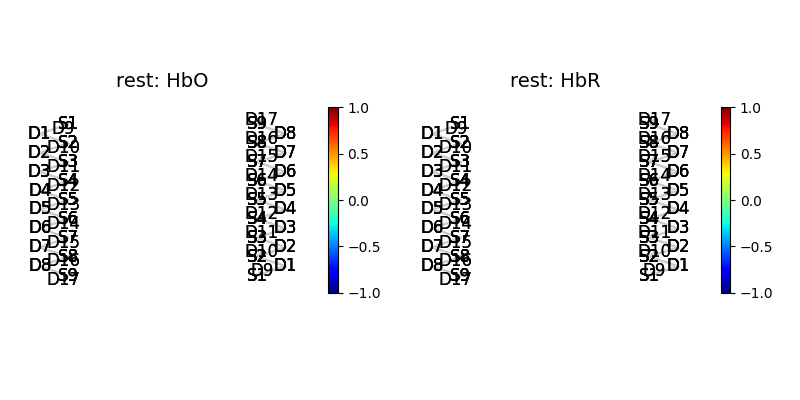

In [19]:
dyads[0]['hyper_ar'].show(thres=0.05, threshold_type='q')

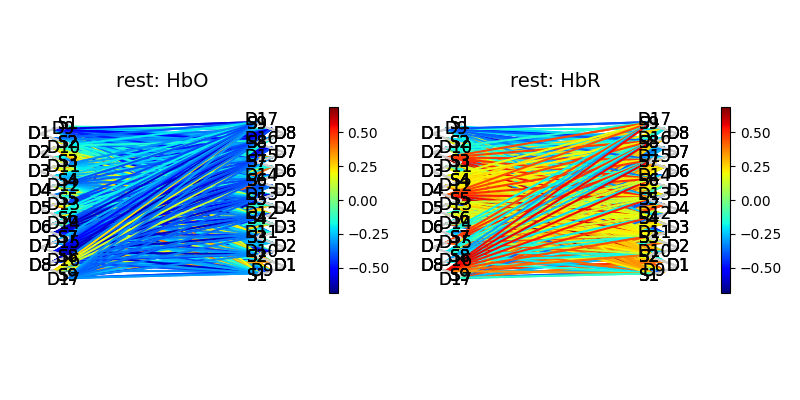

In [20]:
dyads[0]['hyper_corr'].show(thres=0.05, threshold_type='q')

Remembering that there should NOT be any correlation between these subjects, the results of the correlation model
are quite alarmingly bad.